# Smart Beach - Phase 6

## Overview

The **Smart Beach project**, led by the **Municipal Innovation Council (MIC)**, is a three-year pilot initiative focused on enhancing beach safety in Bruce County through the integration of innovative technologies and applied research. It aims to build a real-time warning system for both weather conditions and crowd density, powered by machine learning and computer vision.

As part of **Phase 6** during the Winter 2025 academic term, our student team contributes to the project by **laying the foundation for the weather prediction component** of **Port Elgin Beach** and **Southampton**. While the new beach imagery required for crowd monitoring is scheduled to be collected during the upcoming summer, our current focus is on evaluating the use of external **weather APIs**, buoy sensor data, and model retraining strategies to support multi-beach generalization.

## 1. Environment Setup

### 1.1 Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

root_dir = '/content/drive/MyDrive'

for dirpath, dirnames, filenames in os.walk(root_dir):
    for fname in filenames:
        print(os.path.join(dirpath, fname))

/content/drive/MyDrive/Copy of sample_for_manual_label.gsheet
/content/drive/MyDrive/Colab Notebooks/Smart Beach - Phase 6/Smart_Beach-Phase_6.ipynb
/content/drive/MyDrive/Colab Notebooks/Smart Beach - Phase 6/Wiarton_Airport_2019-2025.csv


### 1.2 Import Library

In [3]:
!pip install --upgrade tensorflow

In [5]:

import numpy as np
import pandas as pd
from datetime import datetime, timedelta

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import matplotlib.pyplot as plt
import seaborn as sns


## 2. Data Processing

### 2.1 Load & Explore Data

In [6]:
import pandas as pd

# 1. Load Data
file_path = '/content/drive/MyDrive/Colab Notebooks/Smart Beach - Phase 6/Wiarton_Airport_2019-2025.csv'
df = pd.read_csv(file_path)

# 2. Explore Data
print(df.head())
print("=== Data Info ===")
print(df.info())
missing_counts = df.isnull().sum()
print("=== Missing Values per Column ===")
print(missing_counts)

# Calculate the percentage of missing values for each column
missing_percent = df.isnull().mean() * 100
print("\n=== Missing Values Percentage per Column ===")
print(missing_percent)

       date  tavg  tmin  tmax  prcp   snow   wdir  wspd  wpgt    pres  tsun
0  2019/1/1  -6.5 -13.4   0.4   2.2   40.0  353.0  11.7  48.0  1018.7   NaN
1  2019/1/2  -8.8 -15.9  -1.6   3.6   40.0  138.0  10.7   NaN  1022.1   NaN
2  2019/1/3  -0.6  -2.5   1.3   0.0  100.0  242.0  21.7  58.0  1011.2   NaN
3  2019/1/4   1.3  -0.7   3.2   0.0   80.0  230.0  18.9  46.0  1006.3   NaN
4  2019/1/5   1.7  -0.2   3.5   0.0   40.0  262.0  10.3  37.0  1006.0   NaN
=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2339 entries, 0 to 2338
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    2339 non-null   object 
 1   tavg    2331 non-null   float64
 2   tmin    2331 non-null   float64
 3   tmax    2331 non-null   float64
 4   prcp    2313 non-null   float64
 5   snow    487 non-null    float64
 6   wdir    2268 non-null   float64
 7   wspd    2330 non-null   float64
 8   wpgt    1001 non-null   float64
 9   pres   

## 2.2 Processing Data

#### 2.2.1 Deal with Missing Value
- Convert date column & sort by date
- Drop columns that are almost entirely empty (tsun);
- Fill remaining missing values (without dropping any rows)
- Final check to ensure there are no NaNs left


In [7]:
# Convert date column & sort by date
df['date'] = pd.to_datetime(df['date'], format='%Y/%m/%d')
df = df.sort_values('date').reset_index(drop=True)

# Drop columns that are almost entirely empty (tsun)
if 'tsun' in df.columns:
    df = df.drop(columns=['tsun'])
if 'snow' in df.columns:
    df = df.drop(columns=['snow'])
if 'wpgt' in df.columns:
    df = df.drop(columns=['wpgt'])

# Fill remaining missing values (without dropping any rows)
num_cols = ['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres']
df[num_cols] = df[num_cols].interpolate(method='linear', limit_direction='both')
# For any still-missing values, fill with the column mean to ensure no rows are dropped
for col in num_cols:
    if df[col].isna().any():
        mean_val = df[col].mean(skipna=True)
        df[col] = df[col].fillna(mean_val)

# Final check to ensure there are no NaNs left
assert df[num_cols].isna().sum().sum() == 0, "There are still missing values—please check"
print(df.head())

        date  tavg  tmin  tmax  prcp   wdir  wspd    pres
0 2019-01-01  -6.5 -13.4   0.4   2.2  353.0  11.7  1018.7
1 2019-01-02  -8.8 -15.9  -1.6   3.6  138.0  10.7  1022.1
2 2019-01-03  -0.6  -2.5   1.3   0.0  242.0  21.7  1011.2
3 2019-01-04   1.3  -0.7   3.2   0.0  230.0  18.9  1006.3
4 2019-01-05   1.7  -0.2   3.5   0.0  262.0  10.3  1006.0


### 2.2.2 Construct Derived Features
- Encode wind direction as sine and cosine components: (a) Convert original 'wdir' from degrees (0~360°) to radians; (b) Compute sin and cos of the wind direction
- Create a binary precipitation flag (1 if any precipitation, 0 otherwise)

In [8]:
df['wdir_rad'] = np.deg2rad(df['wdir'])          # Convert degrees to radians
df['sin_wdir'] = np.sin(df['wdir_rad'])          # Sine encoding of wind direction
df['cos_wdir'] = np.cos(df['wdir_rad'])          # Cosine encoding of wind direction

df['prcp_flag'] = (df['prcp'] > 0).astype(int)   # when prcp > 0, else 0

print(df.head())


        date  tavg  tmin  tmax  prcp   wdir  wspd    pres  wdir_rad  sin_wdir  \
0 2019-01-01  -6.5 -13.4   0.4   2.2  353.0  11.7  1018.7  6.161012 -0.121869   
1 2019-01-02  -8.8 -15.9  -1.6   3.6  138.0  10.7  1022.1  2.408554  0.669131   
2 2019-01-03  -0.6  -2.5   1.3   0.0  242.0  21.7  1011.2  4.223697 -0.882948   
3 2019-01-04   1.3  -0.7   3.2   0.0  230.0  18.9  1006.3  4.014257 -0.766044   
4 2019-01-05   1.7  -0.2   3.5   0.0  262.0  10.3  1006.0  4.572763 -0.990268   

   cos_wdir  prcp_flag  
0  0.992546          1  
1 -0.743145          1  
2 -0.469472          0  
3 -0.642788          0  
4 -0.139173          0  


### 2.2.3 Feature Selection & Sequence Generation
- Select Features: 'tavg', 'tmin', 'tmax', 'wspd', 'pres', 'sin_wdir', 'cos_wdir', 'prcp_flag'
- Generate time series sequences (Windows = 7)

In [9]:
# list of features to use (8 in total)
feature_cols = [
    'tavg', 'tmin', 'tmax',
    'wspd', 'pres',
    'sin_wdir', 'cos_wdir',
    'prcp_flag'
]
df = df.set_index('date')
X_full_raw = df[feature_cols].values

# Normalize all features together using Min-Max scaling
scaler = MinMaxScaler()
X_full_scaled = scaler.fit_transform(X_full_raw)

# Define a function to split data into “past 7 days → predict day 8” samples
def create_multivariate_sequences(X_scaled, look_back=7):
    Xs, ys = [], []
    total_len, n_features = X_scaled.shape
    for i in range(total_len - look_back):
        Xs.append(X_scaled[i : i + look_back, :])    # Data for the past look_back days
        ys.append(X_scaled[i + look_back, :])        # The 8 values to predict for day look_back + 1
    return np.array(Xs), np.array(ys)

look_back = 7
X_seq, y_seq = create_multivariate_sequences(X_full_scaled, look_back=look_back)

# Check dimensions
print("X_seq.shape =", X_seq.shape)  # (num_samples, 7, 8)
print("y_seq.shape =", y_seq.shape)  # (num_samples, 8)

# Split into training/validation/test sets in chronological order ---
num_samples = X_seq.shape[0]
train_end = int(num_samples * 0.7)
val_end   = train_end + int(num_samples * 0.15)

X_train = X_seq[:train_end]
y_train = y_seq[:train_end]

X_val   = X_seq[train_end:val_end]
y_val   = y_seq[train_end:val_end]

X_test  = X_seq[val_end:]
y_test  = y_seq[val_end:]

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

X_seq.shape = (2332, 7, 8)
y_seq.shape = (2332, 8)
Training set: (1632, 7, 8) (1632, 8)
Validation set: (349, 7, 8) (349, 8)
Test set: (351, 7, 8) (351, 8)


## 3. LSTM Model

### 3.1 Build LSTM model

In [16]:
model.summary()
n_timesteps = look_back        # 7 timesteps to look back in the input sequence
n_features  = X_train.shape[2] # 8 features in each input vector
n_outputs   = y_train.shape[1] # 8 values to predict in the output

model = Sequential([
    # LSTM layer: return_sequences=False means we only output the hidden state from the final timestep
    LSTM(units=64, input_shape=(n_timesteps, n_features)),
    Dropout(rate=0.2),      # Dropout layer to help prevent overfitting
    Dense(units=32, activation='relu'),  # Hidden dense layer with ReLU activation
    Dense(units=n_outputs)  # Output layer producing 8 numeric values (linear activation by default)
])

# Compile the model with optimizer and loss
model.compile(
    optimizer='adam',       # Use the Adam optimizer
    loss='mse',             # Mean squared error loss (suitable for regression)
    metrics=['mae']         # Also monitor mean absolute error as an additional metric
)

model.summary()  # Print the model architecture and parameter counts


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,098 (246.48 KB)

 Trainable params: 21,032 (82.16 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,032 (82.16 KB)

 Trainable params: 21,032 (82.16 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Configure callbacks

In [17]:
callbacks = []

# EarlyStopping: If the validation set loss does not decrease for 10 consecutive epochs, stop training

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True  # 在After stopping, automatically restore to the best performing weight on the validation set
)
callbacks.append(early_stop)

# ModelCheckpoint: Save the best performing model file after each epoch
checkpoint = ModelCheckpoint(
    filepath='best_lstm_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
callbacks.append(checkpoint)


### 3.3 Training Model

In [18]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=2
)


Epoch 1/100

Epoch 1: val_loss improved from inf to 0.07216, saving model to best_lstm_model.h5


51/51 - 2s - 39ms/step - loss: 0.1125 - mae: 0.2639 - val_loss: 0.0722 - val_mae: 0.2027
Epoch 2/100

Epoch 2: val_loss improved from 0.07216 to 0.06941, saving model to best_lstm_model.h5


51/51 - 1s - 20ms/step - loss: 0.0739 - mae: 0.2073 - val_loss: 0.0694 - val_mae: 0.1934
Epoch 3/100

Epoch 3: val_loss improved from 0.06941 to 0.06839, saving model to best_lstm_model.h5


51/51 - 0s - 6ms/step - loss: 0.0702 - mae: 0.1977 - val_loss: 0.0684 - val_mae: 0.1923
Epoch 4/100

Epoch 4: val_loss improved from 0.06839 to 0.06685, saving model to best_lstm_model.h5


51/51 - 0s - 5ms/step - loss: 0.0691 - mae: 0.1942 - val_loss: 0.0668 - val_mae: 0.1860
Epoch 5/100

Epoch 5: val_loss improved from 0.06685 to 0.06675, saving model to best_lstm_model.h5


...

51/51 - 0s - 5ms/step - loss: 0.0578 - mae: 0.1670 - val_loss: 0.0587 - val_mae: 0.1660
Epoch 42/100

Epoch 42: val_loss did not improve from 0.05867
51/51 - 0s - 6ms/step - loss: 0.0577 - mae: 0.1674 - val_loss: 0.0590 - val_mae: 0.1657
Epoch 43/100

Epoch 43: val_loss did not improve from 0.05867
51/51 - 0s - 6ms/step - loss: 0.0574 - mae: 0.1663 - val_loss: 0.0591 - val_mae: 0.1671
Epoch 44/100

Epoch 44: val_loss did not improve from 0.05867
51/51 - 0s - 4ms/step - loss: 0.0576 - mae: 0.1666 - val_loss: 0.0588 - val_mae: 0.1663
Epoch 45/100

Epoch 45: val_loss did not improve from 0.05867
51/51 - 0s - 6ms/step - loss: 0.0577 - mae: 0.1669 - val_loss: 0.0588 - val_mae: 0.1663
Epoch 46/100

Epoch 46: val_loss did not improve from 0.05867
51/51 - 0s - 6ms/step - loss: 0.0573 - mae: 0.1660 - val_loss: 0.0593 - val_mae: 0.1663
Epoch 47/100

Epoch 47: val_loss did not improve from 0.05867
51/51 - 0s - 5ms/step - loss: 0.0573 - mae: 0.1654 - val_loss: 0.0594 - val_mae: 0.1670
Epoch 48/100

51/51 - 0s - 7ms/step - loss: 0.0572 - mae: 0.1659 - val_loss: 0.0583 - val_mae: 0.1648
Epoch 49/100

Epoch 49: val_loss did not improve from 0.05829
51/51 - 0s - 6ms/step - loss: 0.0572 - mae: 0.1658 - val_loss: 0.0595 - val_mae: 0.1665
Epoch 50/100

Epoch 50: val_loss did not improve from 0.05829
51/51 - 0s - 5ms/step - loss: 0.0568 - mae: 0.1653 - val_loss: 0.0585 - val_mae: 0.1648
Epoch 51/100

Epoch 51: val_loss did not improve from 0.05829
51/51 - 0s - 7ms/step - loss: 0.0571 - mae: 0.1653 - val_loss: 0.0590 - val_mae: 0.1673
Epoch 52/100

Epoch 52: val_loss did not improve from 0.05829
51/51 - 1s - 12ms/step - loss: 0.0569 - mae: 0.1658 - val_loss: 0.0595 - val_mae: 0.1666
Epoch 53/100

Epoch 53: val_loss did not improve from 0.05829
51/51 - 0s - 7ms/step - loss: 0.0569 - mae: 0.1649 - val_loss: 0.0584 - val_mae: 0.1646
Epoch 54/100

Epoch 54: val_loss did not improve from 0.05829
51/51 - 1s - 10ms/step - loss: 0.0565 - mae: 0.1646 - val_loss: 0.0583 - val_mae: 0.1655
Epoch 55/1

51/51 - 0s - 5ms/step - loss: 0.0569 - mae: 0.1651 - val_loss: 0.0583 - val_mae: 0.1647
Epoch 57/100

Epoch 57: val_loss did not improve from 0.05827
51/51 - 0s - 7ms/step - loss: 0.0566 - mae: 0.1648 - val_loss: 0.0585 - val_mae: 0.1648
Epoch 58/100

Epoch 58: val_loss did not improve from 0.05827
51/51 - 0s - 7ms/step - loss: 0.0563 - mae: 0.1641 - val_loss: 0.0598 - val_mae: 0.1648
Epoch 59/100

Epoch 59: val_loss did not improve from 0.05827
51/51 - 0s - 6ms/step - loss: 0.0565 - mae: 0.1638 - val_loss: 0.0585 - val_mae: 0.1642
Epoch 60/100

Epoch 60: val_loss did not improve from 0.05827
51/51 - 0s - 5ms/step - loss: 0.0562 - mae: 0.1630 - val_loss: 0.0591 - val_mae: 0.1660
Epoch 61/100

Epoch 61: val_loss improved from 0.05827 to 0.05813, saving model to best_lstm_model.h5


51/51 - 0s - 7ms/step - loss: 0.0566 - mae: 0.1648 - val_loss: 0.0581 - val_mae: 0.1644
Epoch 62/100

Epoch 62: val_loss did not improve from 0.05813
51/51 - 1s - 12ms/step - loss: 0.0563 - mae: 0.1633 - val_loss: 0.0585 - val_mae: 0.1647
Epoch 63/100

Epoch 63: val_loss improved from 0.05813 to 0.05789, saving model to best_lstm_model.h5


51/51 - 0s - 5ms/step - loss: 0.0562 - mae: 0.1637 - val_loss: 0.0579 - val_mae: 0.1638
Epoch 64/100

Epoch 64: val_loss did not improve from 0.05789
51/51 - 0s - 5ms/step - loss: 0.0565 - mae: 0.1640 - val_loss: 0.0581 - val_mae: 0.1640
Epoch 65/100

Epoch 65: val_loss did not improve from 0.05789
51/51 - 0s - 5ms/step - loss: 0.0560 - mae: 0.1629 - val_loss: 0.0580 - val_mae: 0.1634
Epoch 66/100

Epoch 66: val_loss did not improve from 0.05789
51/51 - 0s - 6ms/step - loss: 0.0564 - mae: 0.1641 - val_loss: 0.0590 - val_mae: 0.1658
Epoch 67/100

Epoch 67: val_loss did not improve from 0.05789
51/51 - 0s - 6ms/step - loss: 0.0562 - mae: 0.1635 - val_loss: 0.0583 - val_mae: 0.1640
Epoch 68/100

Epoch 68: val_loss did not improve from 0.05789
51/51 - 0s - 8ms/step - loss: 0.0560 - mae: 0.1623 - val_loss: 0.0582 - val_mae: 0.1642
Epoch 69/100

Epoch 69: val_loss did not improve from 0.05789
51/51 - 0s - 5ms/step - loss: 0.0562 - mae: 0.1637 - val_loss: 0.0582 - val_mae: 0.1632
Epoch 70/100

## 4. Visualize & Evaluate Models

### 4.1 Plot training and validation loss & MAE


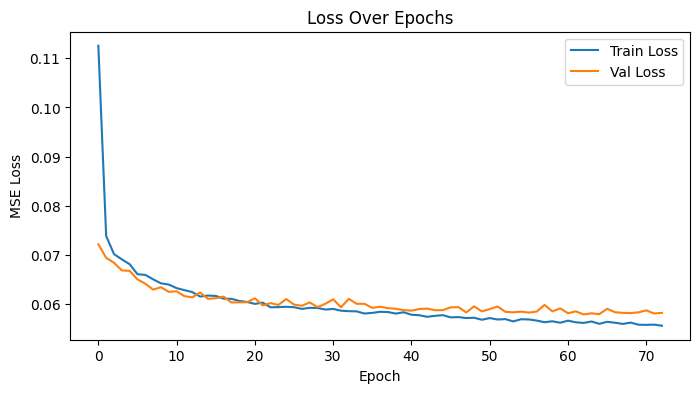

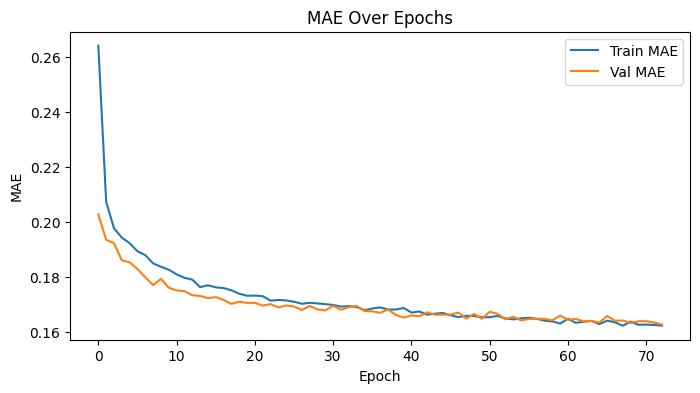

In [19]:
# Loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# MAE
plt.figure(figsize=(8, 4))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

### 4.2 Evaluate on test set

In [20]:
test_metrics = model.evaluate(X_test, y_test, verbose=2)
print(f"Test MSE: {test_metrics[0]:.4f}, Test MAE: {test_metrics[1]:.4f}")


11/11 - 0s - 8ms/step - loss: 0.0545 - mae: 0.1618
Test MSE: 0.0545, Test MAE: 0.1618


### 4.3 Anti-scaling

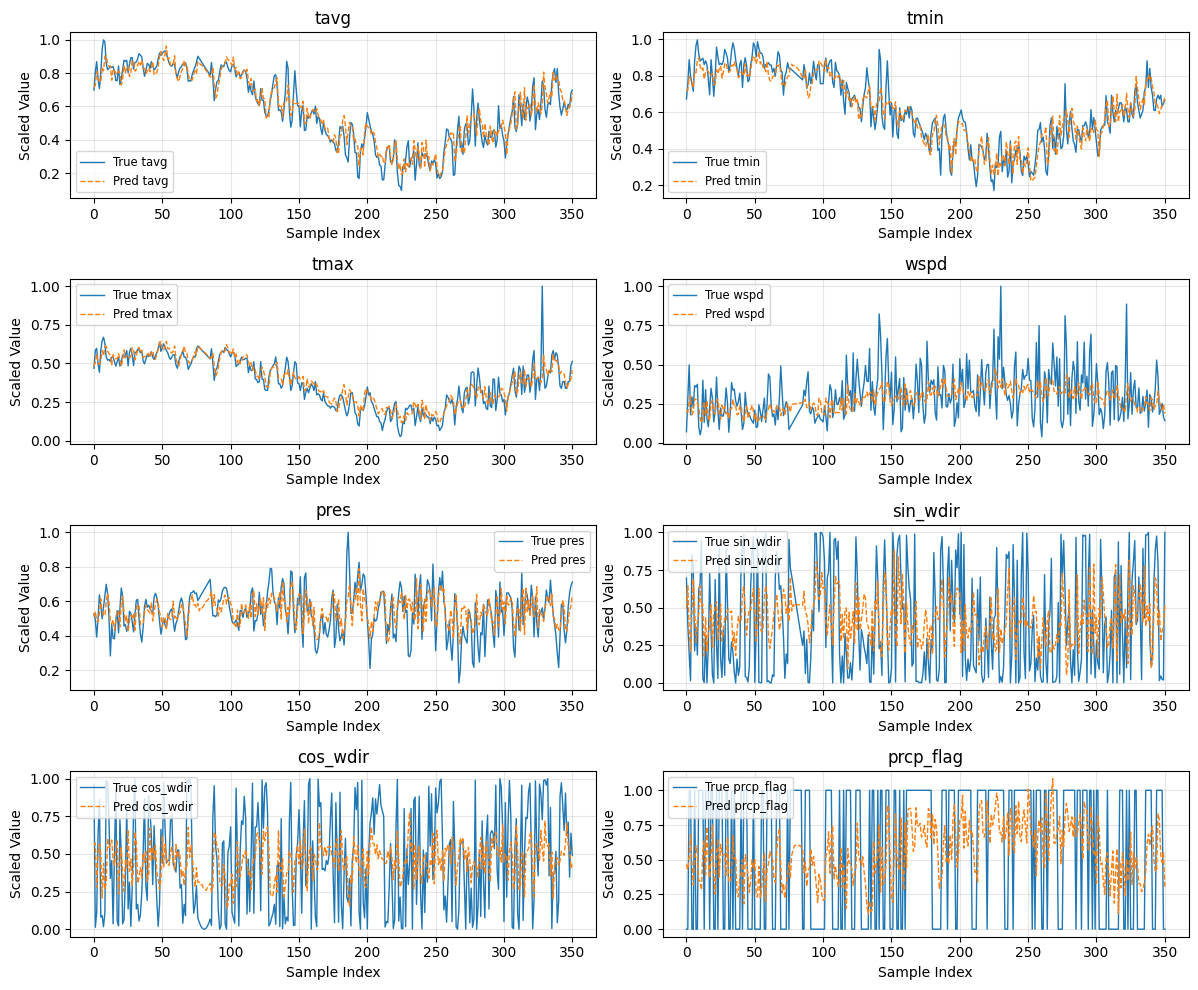

In [22]:
n_features = len(feature_cols)
n_rows = 4
n_cols = 2

plt.figure(figsize=(12, 10))
for i, feat in enumerate(feature_cols):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    ax.plot(y_test[:, i], label=f"True {feat}", linewidth=1)
    ax.plot(y_pred_scaled[:, i], label=f"Pred {feat}", linewidth=1, linestyle='--')
    ax.set_title(feat)
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Scaled Value")
    ax.legend(fontsize='small')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Conclusion & Next Plan
### 5.1 Problem
- Training a single LSTM to predict all eight features (tavg, tmin, tmax, wspd, pres, sin\_wdir, cos\_wdir, prcp\_flag) forces the network’s capacity to be shared between low-frequency signals (e.g., temperature) and high-frequency/noise-like signals (e.g., wind speed/direction), so we plan:
- A single LSTM layer with 64 units (plus one small Dense layer) is sufficient to learn the broad seasonal trend in temperature but is too limited to capture the rapid, high-frequency fluctuations in wind speed and wind direction.
- Using a standard MSE loss causes the model to gravitate toward the “overall mean,” making it insensitive to large, abrupt changes (high-frequency noise).
- We only used wind direction’s sine/cosine encoding and raw scaled values; the model has no explicit information about month or day of year, making it harder to learn the annual cycle.
- A fixed look\_back of 7 days may not be optimal for all features: temperature might benefit from a 30-day window, whereas wind speed may only need 3 days to model its noise.
- All performance metrics (MSE, MAE) and plots so far have been computed on normalized values. This makes it hard for stakeholders to gauge real-world error in degrees Celsius or hPa.

### 5.2 Next Plan

1. Build one LSTM that outputs **only** tavg/tmin/tmax. This allows the model to devote all of its hidden-state capacity to capturing smooth, seasonal temperature patterns.
2. Create a separate model for wind speed and wind direction, which are inherently more volatile.
3. Experiment with Model Architectures:
4. Refine Loss Function & Training Schedule
5. Incorporate Seasonality & Periodic Features
6. Optimize Sliding Window Strategy: (a) Conduct a quick experiment to compare look\_back = 3, 7, 14, and 30 days. Track validation MAE for temperature and wind separately; (b) If feasible, prototype a **multi-scale** model that ingests both a short (3-day) and a long (14-day) window in parallel, concatenates their outputs, and then makes predictions.
7. Enhanced Visualization for Analysis;